# Short-term stock market prediction with Time Series Transformer Network	

### Setting up the environment:

In [1]:
# Install Libraries.

%pip install -q transformers

%pip install -q datasets

%pip install -q evaluate

%pip install -q accelerate

%pip install -q gluonts ujson

%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datasets

c:\Users\ebook\Documents\1) School\0) UCSD\ECE 176\Final Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Import datasets

# import kagglehub
# # Download latest version
# path = kagglehub.dataset_download("surajjha101/dow-jones-30-index-at-1minute-resolution")
# print("Path to dataset files:", path)


#let's use Pandas to preprocess, before converting to HuggingFace dataset

dataset = pd.read_csv("datasets/Kaggle_Dow_Jones_30_Historical_Data.csv")
dataset.replace('?', np.nan, inplace=True)
#refer to medium_version for preprocessing

dataset

,Date,MMM,American Express,Boeing,Caterpillar,Coca Cola,IBM,Intel,J&J,JPMorgan,McDonalds,Merck & Co.,Microsoft,Procter & Gamble,The Home Depot,Walmart,Walt Disney,DJIA
0,4/1/1999,20.22,25.81,21.70,12.80,16.39,49.38,18.35,26.47,27.39,26.31,31.84,29.28,27.03,26.20,30.97,24.09,9832.51
1,4/5/1999,20.29,26.76,21.94,13.38,16.27,51.31,19.36,26.68,27.18,26.74,31.15,30.00,27.69,26.84,31.68,24.09,10007.33
2,4/6/1999,20.00,26.29,21.98,13.19,16.09,51.05,19.80,26.50,27.35,26.56,31.10,29.72,27.63,26.49,31.78,23.42,9963.49
3,4/7/1999,19.82,26.97,22.30,13.23,15.85,52.03,20.06,26.68,29.12,26.96,31.94,29.48,27.66,27.05,32.39,25.14,10085.31
4,4/8/1999,19.93,27.25,22.14,13.26,16.37,52.17,19.90,27.35,30.33,27.03,32.51,29.88,27.66,28.38,33.96,26.05,10197.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5785,3/28/2022,149.47,189.70,188.16,221.85,61.92,131.47,51.51,177.83,140.87,242.94,81.21,310.70,153.88,314.28,146,138.72,34707.94
5786,3/29/2022,152.08,190.94,193.80,221.04,62.16,131.94,52.25,177.74,141.18,248.17,81.57,315.41,155.46,317.71,147.23,142.38,34861.24
5787,3/30/2022,151.43,189.76,194.91,223.08,62.21,132.13,51.43,179.59,NaN,249.03,82.40,313.86,154.39,308.46,149.87,140.96,34955.89
5788,3/31/2022,148.88,187.00,191.50,222.82,62.00,130.02,49.56,177.23,136.32,247.28,82.05,308.31,152.80,299.33,148.92,137.16,35294.19


In [9]:
window_length=5
forecast_length=5

#split into train and test datasets
split = 5700
train_data = dataset.iloc[:split, :]
test_data = dataset.iloc[split:, :] 

def preprocess(data, window_length = window_length, forecast_length = forecast_length):
    #flatten all stocks into one column  
    data = data.iloc[:, 1:].melt()
    data = data.iloc[:, 1]

    data = pd.to_numeric(data).to_numpy() #faster to do slicing operation as numpy array than pandas
    time_length = data.size
    data_windowed = []# np.empty((0)
    for window_index in np.arange( np.random.randint(0,window_length-1), time_length-window_length-forecast_length, window_length):  
        window = np.array(data[window_index:window_index+window_length])
        window = window-np.min(window)
        window = window/np.max(window)
        data_windowed = data_windowed.append(window)#np.append(data_windowed, window, axis=0)
    
   #data_windowed = np.asarray(data_windowed) #convert list to numpy array
    return data_windowed


train_data = preprocess(train_data)
test_data = preprocess(test_data)
#print(test_data.dtype)


AttributeError: 'NoneType' object has no attribute 'append'

In [7]:
#print(type(train_data[1, 1]))
# train_data = pd.DataFrame(train_data)
# test_data = pd.DataFrame(test_data)
train_data

array([1.        , 0.30769231, 0.73076923, ..., 0.18862457, 0.72530889,
       1.        ])

In [11]:
# Initialize Time Series Transformer model
# Get lags and time
from gluonts.time_feature import get_lags_for_frequency
from gluonts.time_feature import time_features_from_frequency_str

freq = '1D' #still not sure freq does - or if we need it
lags_sequence = get_lags_for_frequency(freq)

time_features = time_features_from_frequency_str(freq)

# Initialization begins here
from transformers import TimeSeriesTransformerConfig, TimeSeriesTransformerForPrediction

config = TimeSeriesTransformerConfig(
    prediction_length=forecast_length, # from above
    # context length:
    context_length=window_length,
    # lags coming from helper given the freq:
    lags_sequence=lags_sequence,
    # we'll add 2 time features ("month of year" and "age", see further):
    num_time_features=len(time_features) + 1,
    # we have a single static categorical feature, namely time series ID:
    num_static_categorical_features=1,
    # it has 366 possible values:
    cardinality=[len(train_data)],
    # the model will learn an embedding of size 2 for each of the 366 possible values:
    embedding_dimension=[2],
    
    # transformer params:
    encoder_layers=4,
    decoder_layers=4,
    d_model=32,

)

model = TimeSeriesTransformerForPrediction(config)


In [ ]:
# Prepare Data Loaders
from typing import Iterable

import torch
from gluonts.itertools import Cached, Cyclic
from gluonts.dataset.loader import as_stacked_batches
from transformers import PretrainedConfig

from gluonts.transform.sampler import InstanceSampler
from typing import Optional

def create_train_dataloader(
    config: PretrainedConfig,
    freq,
    data,
    batch_size: int,
    num_batches_per_epoch: int,
    shuffle_buffer_length: Optional[int] = None,
    cache_data: bool = True,
    **kwargs,
) -> Iterable:
    
    # PREDICTION_INPUT_NAMES = [  #NOT sure what this does
    #     "past_time_features",
    #     "past_values",
    #     "past_observed_mask",
    #     "future_time_features",
    # ]
    # if config.num_static_categorical_features > 0:
    #     PREDICTION_INPUT_NAMES.append("static_categorical_features")

    # if config.num_static_real_features > 0:
    #     PREDICTION_INPUT_NAMES.append("static_real_features")

    # TRAINING_INPUT_NAMES = PREDICTION_INPUT_NAMES + [
    #     "future_values",
    #     "future_observed_mask",
    # ]
    
    training_instances = data #bypass previous steps
    return as_stacked_batches(
        training_instances,
        batch_size=batch_size,
        shuffle_buffer_length=shuffle_buffer_length,
        #field_names=TRAINING_INPUT_NAMES,
        output_type=torch.tensor,
        num_batches_per_epoch=num_batches_per_epoch,
    )

def create_backtest_dataloader(
    config: PretrainedConfig,
    freq,
    data,
    batch_size: int,
    **kwargs,
): 
    # PREDICTION_INPUT_NAMES = [
    #     "past_time_features",
    #     "past_values",
    #     "past_observed_mask",
    #     "future_time_features",
    # ]

    testing_instances = data #bypass previous steps
    return as_stacked_batches(
        testing_instances,
        batch_size=batch_size,
        output_type=torch.tensor,
        #field_names=PREDICTION_INPUT_NAMES,
    )


train_data = datasets.Dataset.from_pandas(train_data)
test_data = datasets.Dataset.from_pandas(test_data)

train_dataloader = create_train_dataloader(
    config=config,
    freq=freq,
    data=train_data,
    batch_size=256,
    num_batches_per_epoch=100,
)

test_dataloader = create_backtest_dataloader(
    config=config,
    freq=freq,
    data=test_data,
    batch_size=64,
)



AttributeError: 'Dataset' object has no attribute 'columns'

In [41]:
# Train the model
from accelerate import Accelerator
from torch.optim import AdamW

accelerator = Accelerator()
device = accelerator.device

model.to(device)
optimizer = AdamW(model.parameters(), lr=6e-4, betas=(0.9, 0.95), weight_decay=1e-1)

model, optimizer, train_dataloader = accelerator.prepare(
    model,
    optimizer,
    train_dataloader,
)

model.train()
for epoch in range(40):
    for index, batch in enumerate(train_dataloader):
        optimizer.zero_grad()
        outputs = model(
            static_categorical_features=batch["static_categorical_features"].to(device)
            if config.num_static_categorical_features > 0
            else None,
            static_real_features=batch["static_real_features"].to(device)
            if config.num_static_real_features > 0
            else None,
            past_time_features=batch["past_time_features"].to(device),
            past_values=batch["past_values"].to(device),
            future_time_features=batch["future_time_features"].to(device),
            future_values=batch["future_values"].to(device),
            past_observed_mask=batch["past_observed_mask"].to(device),
            future_observed_mask=batch["future_observed_mask"].to(device),
        )
        loss = outputs.loss

        # Backpropagation
        accelerator.backward(loss)
        optimizer.step()

        if index % 100 == 0:
            print(loss.item())


KeyError: 'past_values'

In [11]:
# Inference

# For mac users (comment this out otherwise):
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

model.eval()

forecasts = []

for batch in test_dataloader:
    outputs = model.generate(
        static_categorical_features=batch["static_categorical_features"].to(device)
        if config.num_static_categorical_features > 0
        else None,
        static_real_features=batch["static_real_features"].to(device)
        if config.num_static_real_features > 0
        else None,
        past_time_features=batch["past_time_features"].to(device),
        past_values=batch["past_values"].to(device),
        future_time_features=batch["future_time_features"].to(device),
        past_observed_mask=batch["past_observed_mask"].to(device),
    )
    forecasts.append(outputs.sequences.cpu().numpy())


In [12]:
# Forecast Evaluation
%pip install scikit-learn
from evaluate import load
from gluonts.time_feature import get_seasonality

forecasts = np.vstack(forecasts)

mase_metric = load("evaluate-metric/mase")
smape_metric = load("evaluate-metric/smape")

forecast_median = np.median(forecasts, 1)

mase_metrics = []
smape_metrics = []
for item_id, ts in enumerate(test_dataset):
    training_data = ts["target"][:-prediction_length]
    ground_truth = ts["target"][-prediction_length:]
    mase = mase_metric.compute(
        predictions=forecast_median[item_id], 
        references=np.array(ground_truth), 
        training=np.array(training_data), 
        periodicity=get_seasonality(freq))
    mase_metrics.append(mase["mase"])
    
    smape = smape_metric.compute(
        predictions=forecast_median[item_id], 
        references=np.array(ground_truth), 
    )
    smape_metrics.append(smape["smape"])

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------- ----------------------- 4.5/11.1 MB 24.2 MB/s eta 0:00:01
   ------------------------------------- -- 10.5/11.1 MB 26.2 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 22.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/41.0 MB ? eta -:--:--
   -------- ------------------------------- 8.9/41.0 MB 43.7 MB/s eta 0:00:01
   ---------------- ----------------------- 17.0/41.0 MB 41.7 MB/s eta 0:00:01
   ------------------------ --------------- 25.2/41.0 MB 39.9 MB/s eta 0:00:01
   --------------------------------- ------ 33.8/41.0 MB 40.2 MB/s eta 0:00:01
   ---------------------------------------  40.9/41.0 MB 40.0 MB/s eta 0:00:01
   ---------------------------------------- 41.0/41.0 MB 33.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


c:\Users\ebook\Documents\1) School\0) UCSD\ECE 176\Final Project\.venv\Lib\site-packages\gluonts\time_feature\seasonality.py:47: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  offset = pd.tseries.frequencies.to_offset(freq)
c:\Users\ebook\Documents\1) School\0) UCSD\ECE 176\Final Project\.venv\Lib\site-packages\gluonts\time_feature\seasonality.py:47: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  offset = pd.tseries.frequencies.to_offset(freq)
c:\Users\ebook\Documents\1) School\0) UCSD\ECE 176\Final Project\.venv\Lib\site-packages\gluonts\time_feature\seasonality.py:47: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  offset = pd.tseries.frequencies.to_offset(freq)
c:\Users\ebook\Documents\1) School\0) UCSD\ECE 176\Final Project\.venv\Lib\site-packages\gluonts\time_feature\seasonality.py:47: FutureWarning: 'M' is deprecated and 

In [13]:
print(f"MASE: {np.mean(mase_metrics)}")
print(f"sMAPE: {np.mean(smape_metrics)}")

MASE: 1.5730144983657612
sMAPE: 0.20109123431060155


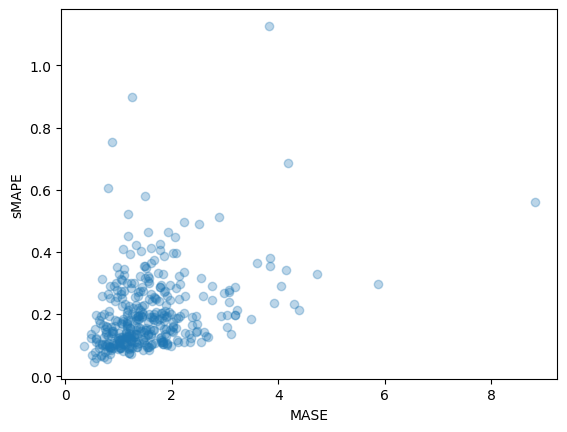

In [14]:
# Plot individual metrics
plt.scatter(mase_metrics, smape_metrics, alpha=0.3)
plt.xlabel("MASE")
plt.ylabel("sMAPE")
plt.show()


In [15]:
# Plot Predictions
import matplotlib.dates as mdates

def plot(ts_index):
    fig, ax = plt.subplots()

    index = pd.period_range(
        start=test_dataset[ts_index][FieldName.START],
        periods=len(test_dataset[ts_index][FieldName.TARGET]),
        freq=freq,
    ).to_timestamp()

    # Major ticks every half year, minor ticks every month,
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    ax.plot(
        index[-2*prediction_length:], 
        test_dataset[ts_index]["target"][-2*prediction_length:],
        label="actual",
    )

    plt.plot(
        index[-prediction_length:], 
        np.median(forecasts[ts_index], axis=0),
        label="median",
    )
    
    plt.fill_between(
        index[-prediction_length:],
        forecasts[ts_index].mean(0) - forecasts[ts_index].std(axis=0), 
        forecasts[ts_index].mean(0) + forecasts[ts_index].std(axis=0), 
        alpha=0.3, 
        interpolate=True,
        label="+/- 1-std",
    )
    plt.legend()
    plt.show()


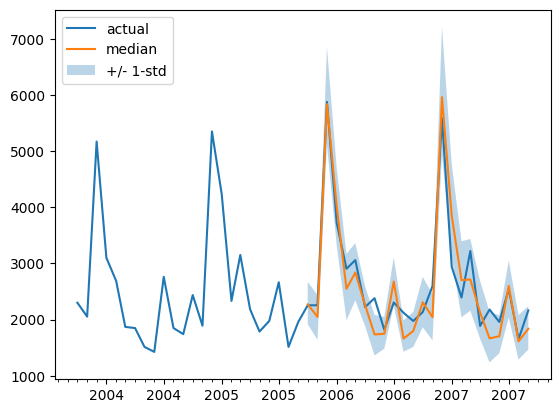

In [16]:
# Plot
plot(334)